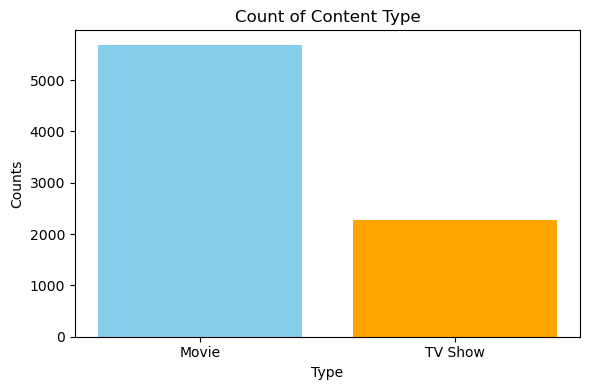

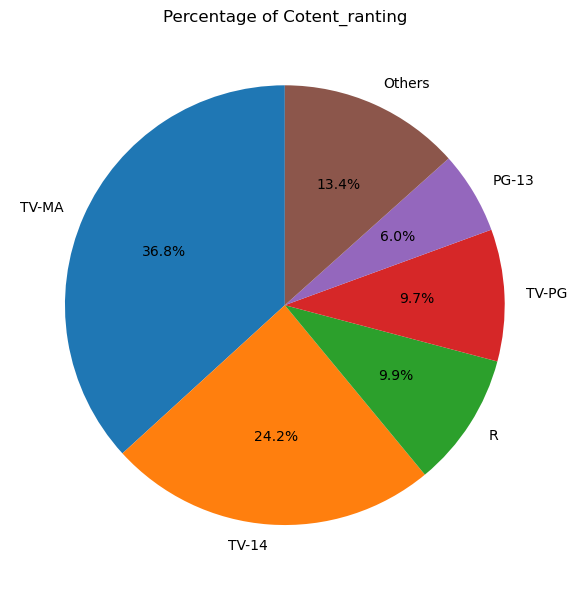

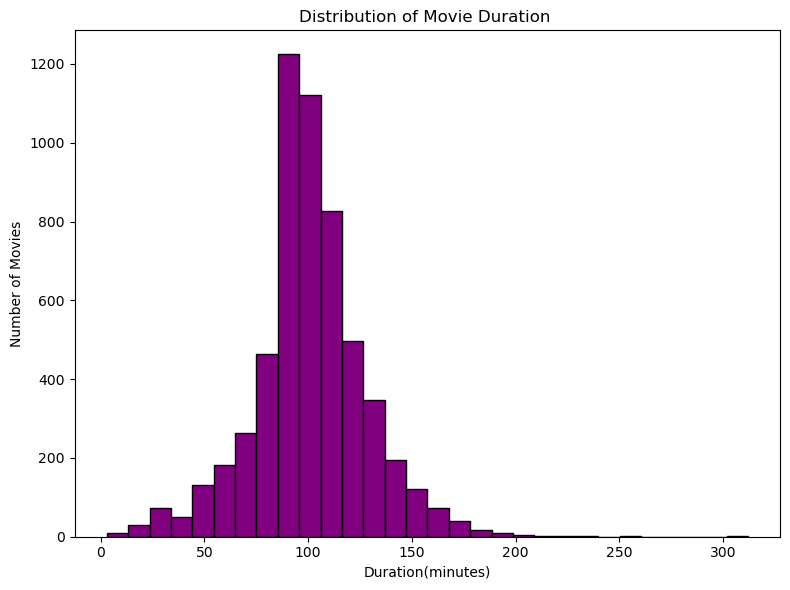

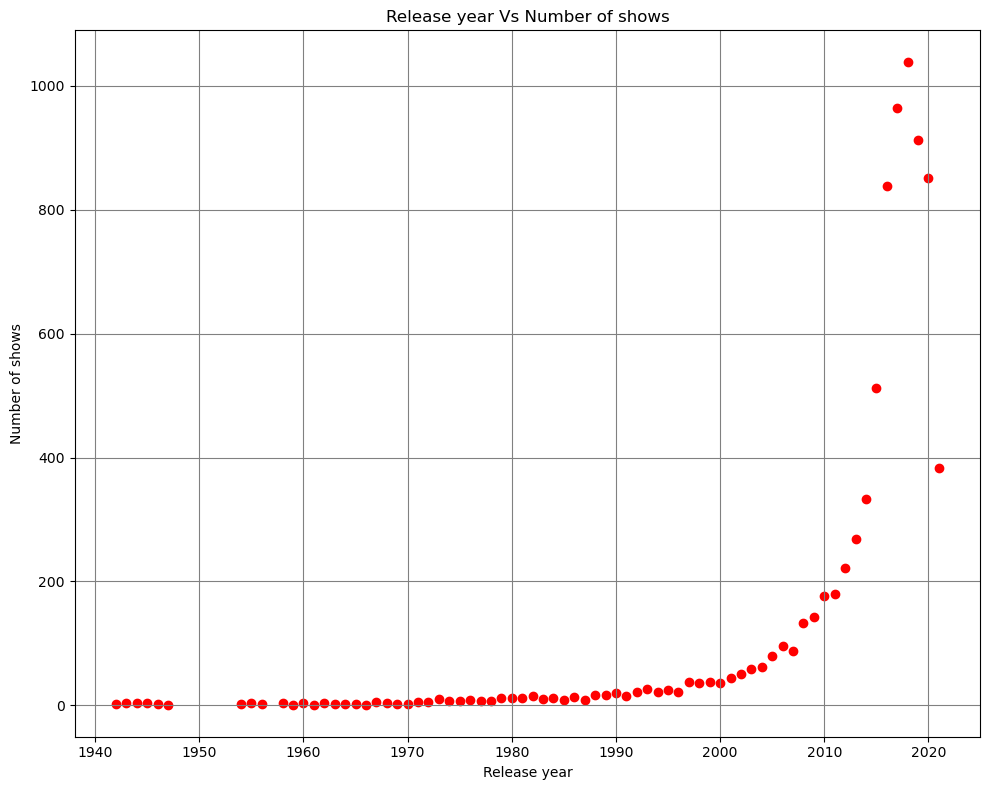

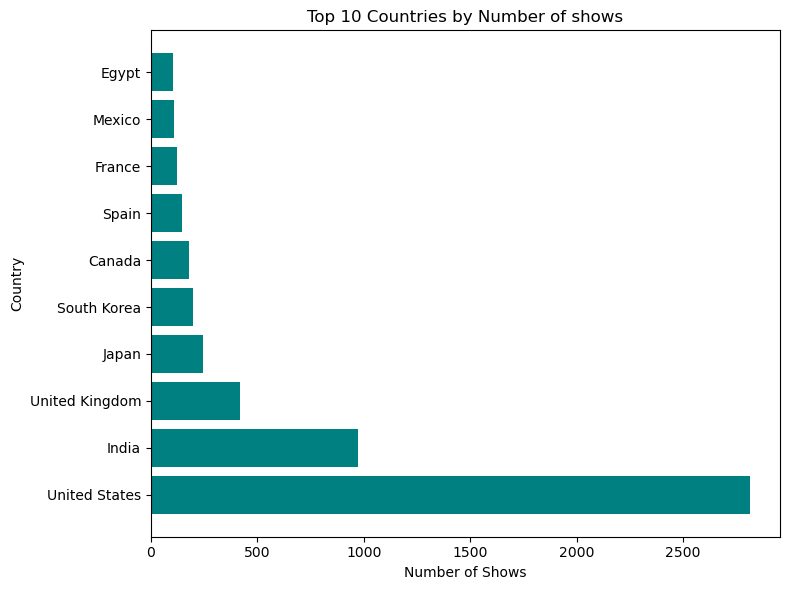

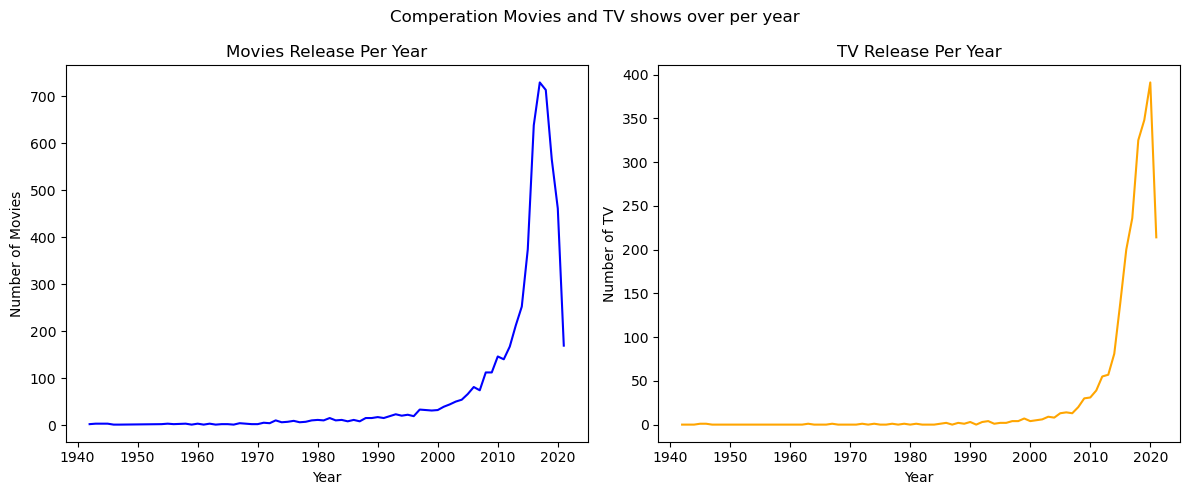

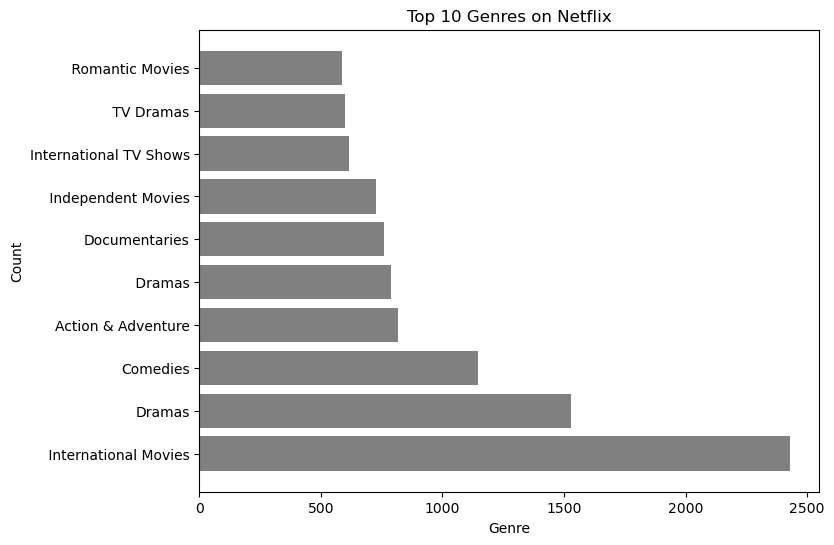

In [10]:
# import the libraries
import pandas as pd
import matplotlib.pyplot as plt

# load the data
df = pd.read_csv('netflix_titles.csv')

# clean data
df = df.dropna(subset=['type','release_year','rating','country','duration'])

# Count and Visualize Content Types Using a Bar Chart
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index,type_counts.values,color=['skyblue','orange'])
plt.title('Count of Content Type')
plt.xlabel('Type')
plt.ylabel('Counts')
plt.tight_layout()
plt.savefig('movies_vs_tv_show.png',dpi=300, bbox_inches='tight')
plt.show()

# Percentage of Movie Content Rating
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
top = rating_counts.head(5)
others = rating_counts[5:].sum()
top['Others'] = others
plt.pie(top , labels=top.index, autopct='%1.1f%%',startangle=90)
plt.title('Percentage of Cotent_ranting')
plt.tight_layout()
plt.savefig('content_rating.png',dpi=300, bbox_inches='tight')
plt.show()

# Movie duration distribution
movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min','').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30,color='purple',edgecolor='black')
plt.title('Distribution of Movie Duration ')
plt.xlabel('Duration(minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movie_duration.png',dpi=300, bbox_inches='tight')
plt.show()

# Release year Vs Number of shows
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,8))
plt.scatter(release_counts.index,release_counts.values,color='red')
plt.grid(color='gray')
plt.title('Release year Vs Number of shows')
plt.xlabel('Release year')
plt.ylabel('Number of shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png',dpi=300, bbox_inches='tight')
plt.show()

# Top 10 countries of Shows
country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index,country_counts.values,color='teal')
plt.title('Top 10 Countries by Number of shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('countries.png',dpi=300, bbox_inches='tight')
plt.show()

# Movies and TV show comperation
content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)
fig,ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title('Movies Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

ax[1].plot(content_by_year.index,content_by_year['TV Show'],color='orange')
ax[1].set_title('TV Release Per Year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV')

fig.suptitle('Comperation Movies and TV shows over per year')
plt.tight_layout()
plt.savefig('movies_tv_shows.png',dpi=300, bbox_inches='tight')
plt.show()

total_genres = df['listed_in'].str.split(',').explode().value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(total_genres.index,total_genres.values,color='gray')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()
